In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

uploaded = files.upload()


Saving Online Retail .xlsx to Online Retail .xlsx


In [ ]:
df = pd.read_excel("Online Retail .xlsx")
df.head()
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
#data cleaning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df_clean = df.dropna(subset=['CustomerID', 'Quantity', 'UnitPrice'])

# keep postive quantity and price
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# remove the return invoice （InvoiceNo 以 'C' 开头）
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# confirm data cleaning
print("Clean dataset shape:", df_clean.shape)
print(df_clean[['Quantity','UnitPrice','TotalPrice']].head())


Clean dataset shape: (397884, 9)
   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


**1.RFM**

In [ ]:
#2.RFM
import datetime as dt

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Snapshot date（last day+1）
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [ ]:
# 3️⃣ Standard RFM
# =============================
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

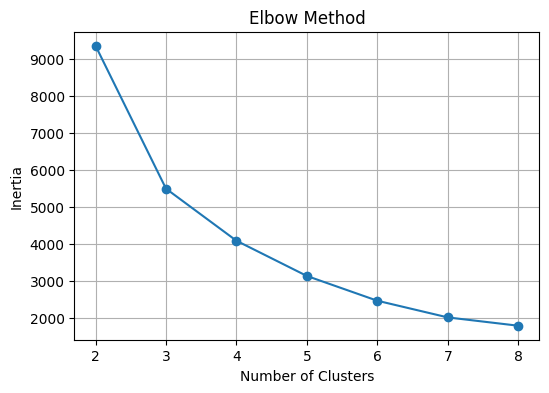

In [ ]:
inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,9), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
#4 K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())
print(rfm['Cluster'].value_counts())

   CustomerID  Recency  Frequency  Monetary  Cluster  anomaly_score  \
0     12346.0      326          1  77183.60        3             -1   
1     12347.0        2          7   4310.00        0              1   
2     12348.0       75          4   1797.24        0              1   
3     12349.0       19          1   1757.55        0              1   
4     12350.0      310          1    334.40        1              1   

   lof_anomaly  combined_anomaly  
0           -1                -1  
1            1                 1  
2            1                 1  
3           -1                -1  
4            1                 1  
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


In [ ]:
#Step 7. PCA as Preprocessing

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.55502102 0.30249315]
Total explained variance: 0.8575141741259507


In [ ]:
#Step 8. PCA after K-Means
kmeans_pca = KMeans(n_clusters=4, random_state=42)
rfm['Cluster_PCA'] = kmeans_pca.fit_predict(rfm_pca)

print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Cluster_PCA']].head())
print(rfm['Cluster_PCA'].value_counts())


   CustomerID  Recency  Frequency  Monetary  Cluster  Cluster_PCA
0     12346.0      326          1  77183.60        3            3
1     12347.0        2          7   4310.00        0            0
2     12348.0       75          4   1797.24        0            0
3     12349.0       19          1   1757.55        0            0
4     12350.0      310          1    334.40        1            1
Cluster_PCA
0    3086
1    1070
3     170
2      12
Name: count, dtype: int64


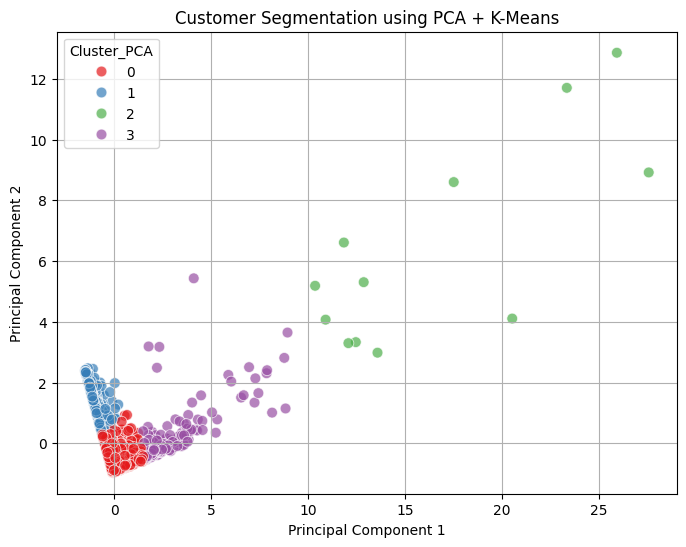

In [ ]:
#Step 9. PCA + K-Means vision
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=rfm_pca[:, 0],
    y=rfm_pca[:, 1],
    hue=rfm['Cluster_PCA'],
    palette='Set1',
    s=60,
    alpha=0.7
)

plt.title("Customer Segmentation using PCA + K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

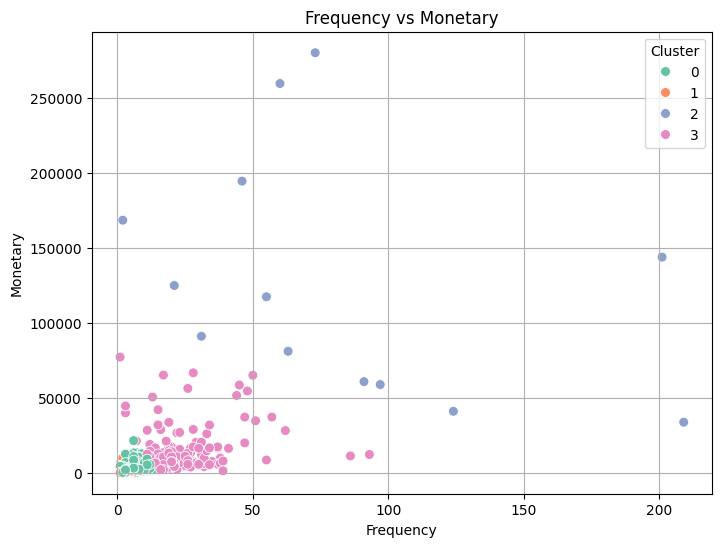

In [ ]:

#  Frequency vs Monetary
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=50
)
plt.title("Frequency vs Monetary")
plt.grid(True)
plt.show()

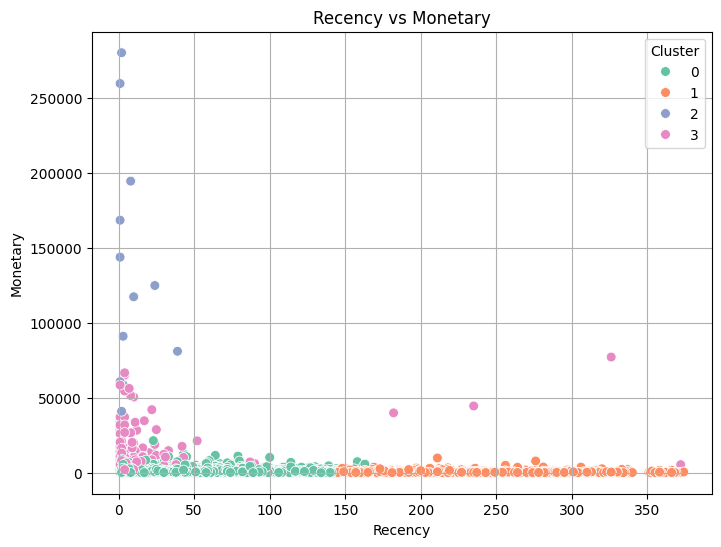

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=50
)
plt.title("Recency vs Monetary")
plt.grid(True)
plt.show()

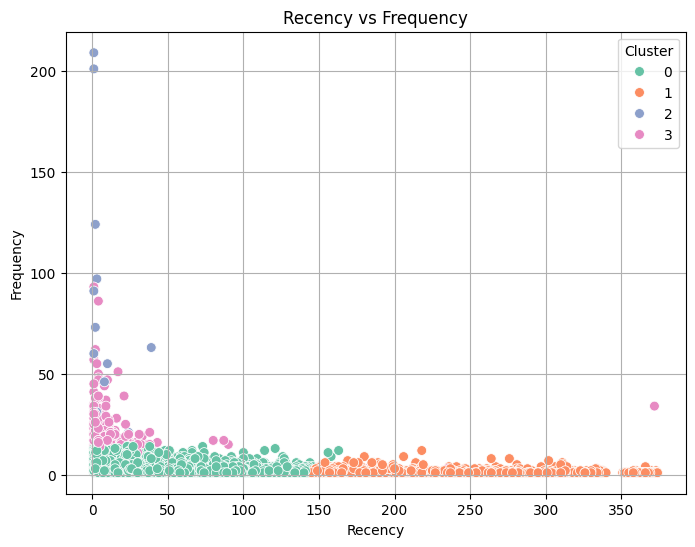

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='Set2',
    s=50
)
plt.title("Recency vs Frequency")
plt.grid(True)
plt.show()

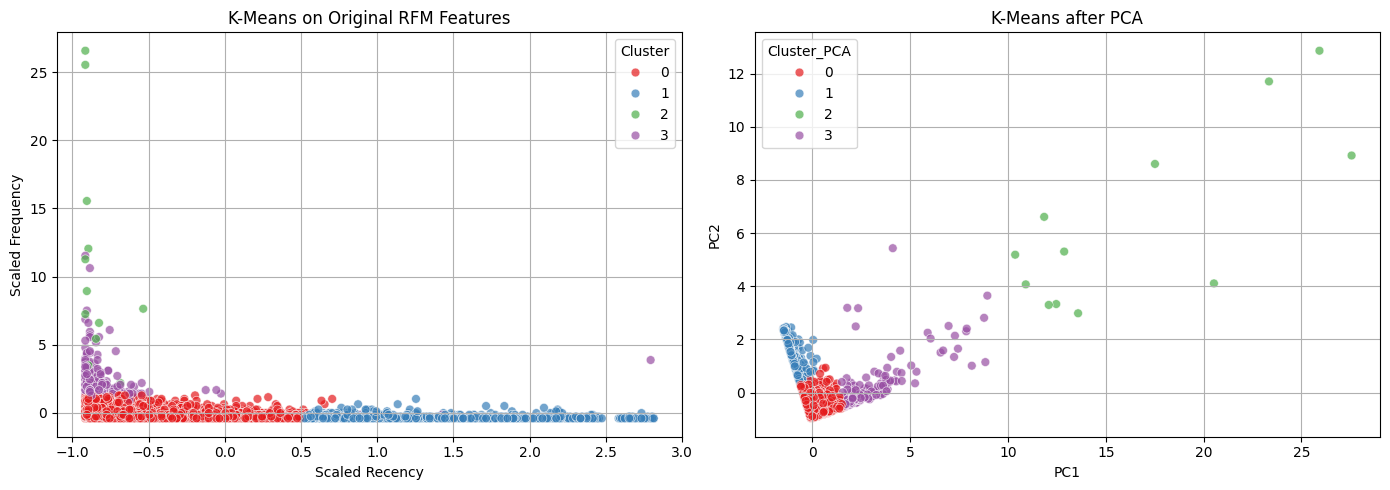

In [ ]:
#Step 10. original K-Means vs PCA K-Means comparison
plt.figure(figsize=(14, 5))

# Left：original RFM
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=rfm_scaled[:, 0],   # Scaled Recency
    y=rfm_scaled[:, 1],   # Scaled Frequency
    hue=rfm['Cluster'],
    palette='Set1',
    s=40,
    alpha=0.7
)
plt.title("K-Means on Original RFM Features")
plt.xlabel("Scaled Recency")
plt.ylabel("Scaled Frequency")
plt.grid(True)

# PCA
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=rfm_pca[:, 0],
    y=rfm_pca[:, 1],
    hue=rfm['Cluster_PCA'],
    palette='Set1',
    s=40,
    alpha=0.7
)
plt.title("K-Means after PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.tight_layout()
plt.show()



In [ ]:
cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary

,CustomerID,Recency,Frequency,Monetary,anomaly_score,lof_anomaly,combined_anomaly,Cluster_PCA
Cluster,,,,,,,,
0,15289.128356,43.702685,3.682711,1359.049284,1.000000,0.996726,0.996726,0.002620
1,15347.791940,248.075914,1.552015,480.617480,0.998126,0.951265,0.951265,0.998126
2,15435.000000,7.384615,82.538462,127338.313846,-1.000000,-0.076923,-1.000000,2.076923
3,15212.857843,15.500000,22.333333,12709.090490,0.705882,0.941176,0.705882,2.470588


Analysis:
1.**Cluster 2**
Recency: 7 days
Frequency: 82 purchases
Monetary: £127,338
**Characteristics:**
Purchased very recently
Extremely high purchase frequency
Exceptionally high total spending
So, it shows that High-Value Loyal Customers
**Recommended Marketing Strategies:**
Exclusive VIP discounts
Premium product recommendations
Loyalty or membership programs
Early access to new product launches
2.**Cluster 3**
Recency: 15 days
Frequency: 22 purchases
Monetary: £12,709
**Characteristics:**
Purchase relatively frequently
High spending level
Still recently active
It shows that Strong Loyal Customers
Although not as extreme as Cluster 2, they remain a core customer segment and contribute significantly to revenue.
3.**Cluster 0**
Recency: 43 days
Frequency: 3.6 purchases
Monetary: £1,359
**Characteristics:**
Purchase occasionally
Moderate spending
Have not purchased very recently
It shows that Occasional / Moderate Customers
They may respond well to targeted promotions or personalized offers to increase purchase frequency.
4.**Cluster 1**
Recency: 248 days
Frequency: 1.5 purchases
Monetary: £480
**Characteristics:**
Long time since last purchase
Very low purchase frequency
Lowest spending among all clusters
It shows that Churned or At-Risk Customers
They may have already disengaged from the business.
**In addition:**Cluster 2 has a Monetary value of £127,338, which is significantly higher than all other segments.So we consider those customers are Wholesale buyers,Corporate clients Or potential outliers This results highlights the presence of a small group of customers who contribute disproportionately to total revenue.


**3.Decision Tree classification to interpret RFM clusters and provide interpretable rules.**

In [ ]:
#Step 1: Prepare Features and Target
from sklearn.model_selection import train_test_split

X = rfm[['Recency', 'Frequency', 'Monetary']]

# Target: K-Means cluster labels
y = rfm['Cluster']

# Split into training and test sets for interpretability (not for strict prediction)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Step 2: Train a Shallow Decision Trees
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Shallow tree for interpretability
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Evaluate (optional, just for info)
accuracy = dt.score(X_test, y_test)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

Decision Tree Accuracy: 0.99


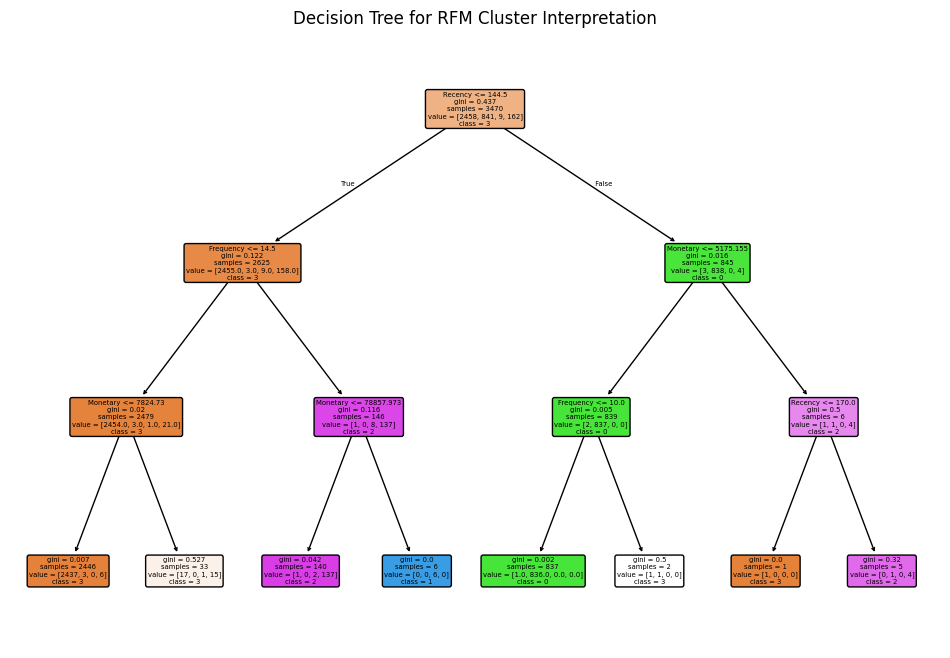

In [ ]:
#Step 3: Visualize the Tree
plt.figure(figsize=(12,8))
tree.plot_tree(
    dt,
    feature_names=['Recency', 'Frequency', 'Monetary'],
    class_names=[str(c) for c in rfm['Cluster'].unique()],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for RFM Cluster Interpretation")
plt.show()

In [ ]:
#Step 4: Extract Rules Programmatically
from sklearn.tree import _tree

def get_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            # Left
            recurse(tree_.children_left[node], path + [f"{name} <= {threshold:.2f}"])
            # Right
            recurse(tree_.children_right[node], path + [f"{name} > {threshold:.2f}"])
        else:
            paths.append((path, tree_.value[node]))

    recurse(0, [])
    return paths

rules = get_rules(dt, ['Recency', 'Frequency', 'Monetary'])

# Print rules
for path, value in rules:
    print("IF " + " AND ".join(path) + f" THEN Cluster distribution: {value}")



IF Recency <= 144.50 AND Frequency <= 14.50 AND Monetary <= 7824.73 THEN Cluster distribution: [[0.99632052 0.00122649 0.         0.00245298]]
IF Recency <= 144.50 AND Frequency <= 14.50 AND Monetary > 7824.73 THEN Cluster distribution: [[0.51515152 0.         0.03030303 0.45454545]]
IF Recency <= 144.50 AND Frequency > 14.50 AND Monetary <= 78857.97 THEN Cluster distribution: [[0.00714286 0.         0.01428571 0.97857143]]
IF Recency <= 144.50 AND Frequency > 14.50 AND Monetary > 78857.97 THEN Cluster distribution: [[0. 0. 1. 0.]]
IF Recency > 144.50 AND Monetary <= 5175.16 AND Frequency <= 10.00 THEN Cluster distribution: [[0.00119474 0.99880526 0.         0.        ]]
IF Recency > 144.50 AND Monetary <= 5175.16 AND Frequency > 10.00 THEN Cluster distribution: [[0.5 0.5 0.  0. ]]
IF Recency > 144.50 AND Monetary > 5175.16 AND Recency <= 170.00 THEN Cluster distribution: [[1. 0. 0. 0.]]
IF Recency > 144.50 AND Monetary > 5175.16 AND Recency > 170.00 THEN Cluster distribution: [[0.  0.

**Rule 1**
IF Recency <= 144.50 AND Frequency <= 14.50 AND Monetary <= 7824.73
THEN Cluster distribution: [[0.996, 0.001, 0.0, 0.002]]
**Interpretation:**
Customers who purchased recently (<145 days ago), not very frequently (≤15 times), and moderate spending (≤£7,824) are overwhelmingly in Cluster 0 (Regular Mid-Value Customers).
Business insight:
These are typical occasional customers; can target with promotions to increase purchase frequency.

**Rule 2**
IF Recency <= 144.50 AND Frequency <= 14.50 AND Monetary > 7824.73
THEN Cluster distribution: [[0.515, 0, 0.03, 0.454]]
**Interpretation:**
Recent but low-frequency customers with high spending are split between Cluster 0 and Cluster 3 (Loyal High-Value Customers).
Business insight:
Likely bulk or wholesale buyers — may need special engagement or VIP offers.

**Rule 3**
IF Recency <= 144.50 AND Frequency > 14.50 AND Monetary <= 78857.97
THEN Cluster distribution: [[0.007, 0, 0.014, 0.979]]
**Interpretation:**
Frequent purchasers with moderate to high spending belong almost entirely to Cluster 3 (Loyal High-Value Customers).
Business insight:
Core loyal customers; focus on retention and personalized recommendations.

**Rule 4**
IF Recency <= 144.50 AND Frequency > 14.50 AND Monetary > 78857.97
THEN Cluster distribution: [[0, 0, 1, 0]]
**Interpretation:**
Customers with very frequent purchases and extremely high spending are Cluster 2 (VIP / Elite Customers).
Business insight:
These are top-tier VIPs; offer exclusive discounts, early product access, and high-end services.

**Rule 5**
IF Recency > 144.50 AND Monetary <= 5175.16 AND Frequency <= 10.00
THEN Cluster distribution: [[0.001, 0.999, 0, 0]]
**Interpretation:**
Customers who haven’t purchased in a long time (>145 days), with low spending and low frequency, are almost entirely Cluster 1 (Lost / Low-Value Customers).
Business insight:
At-risk customers; may need re-engagement campaigns or win-back promotions.

**Rule 6**
IF Recency > 144.50 AND Monetary <= 5175.16 AND Frequency > 10.00
THEN Cluster distribution: [[0.5, 0.5, 0, 0]]
**Interpretation:**
Long time since last purchase but relatively frequent historical buyers — split between Cluster 0 and 1.
Business insight:
Could indicate churned regulars; track reactivation opportunities.

**Rule 7**
IF Recency > 144.50 AND Monetary > 5175.16 AND Recency <= 170.00
THEN Cluster distribution: [[1, 0, 0, 0]]
**Interpretation:**
Customers who purchased somewhat recently, with high spending, are classified in Cluster 0 (Mid-Value).
Business insight:
Likely intermediate buyers or occasional bulk customers.

**Rule 8**
IF Recency > 144.50 AND Monetary > 5175.16 AND Recency > 170.00
THEN Cluster distribution: [[0, 0.2, 0, 0.8]]
**Interpretation:**
Customers who haven’t purchased for a long time, but had high spending, are mainly Cluster 3 (Loyal High-Value) with some Cluster 1.
**Business insight:**
Valuable but dormant customers; prime candidates for VIP reactivation campaigns.

**4.Naive Bayes for Discovery + PCA Visualization**

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(


First 5 rows of discretized features:
   Recency_bin  Frequency_bin  Monetary_bin
0            3              0             3
1            0              2             3
2            2              1             3
3            1              0             3
4            3              0             1

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       917
           1       0.98      0.99      0.99       320
           2       0.00      0.00      0.00         4
           3       0.36      0.82      0.50        61

    accuracy                           0.92      1302
   macro avg       0.58      0.68      0.61      1302
weighted avg       0.95      0.92      0.93      1302

Confusion Matrix:

[[827   5   0  85]
 [  0 318   0   2]
 [  2   0   0   2]
 [ 10   1   0  50]]

Class priors (P(cluster)):
Cluster 0: 0.7039
Cluster 1: 0.2460
Cluster 2: 0.0030
Cluster 3: 0.0471


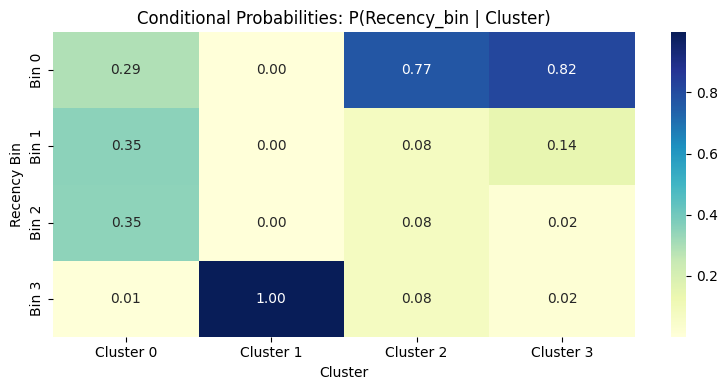

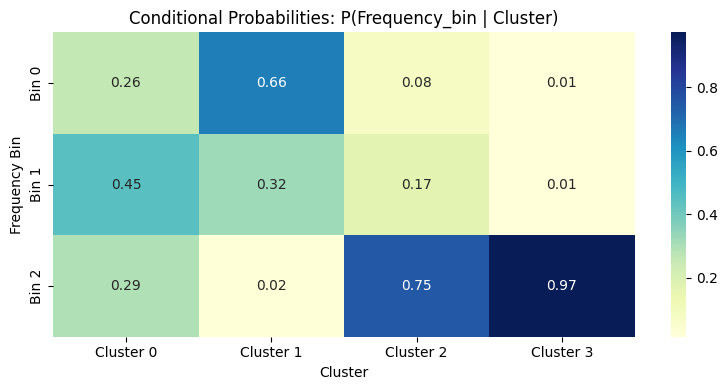

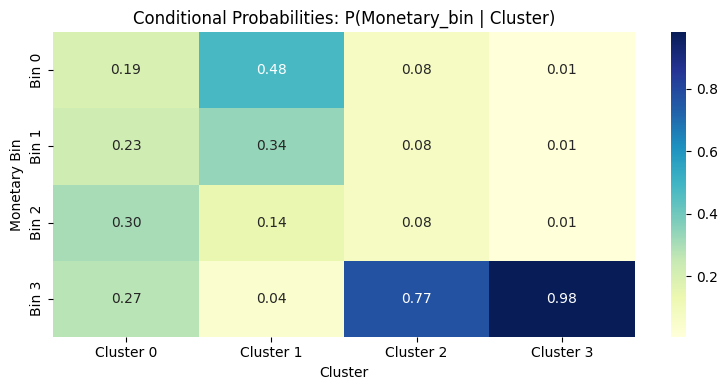

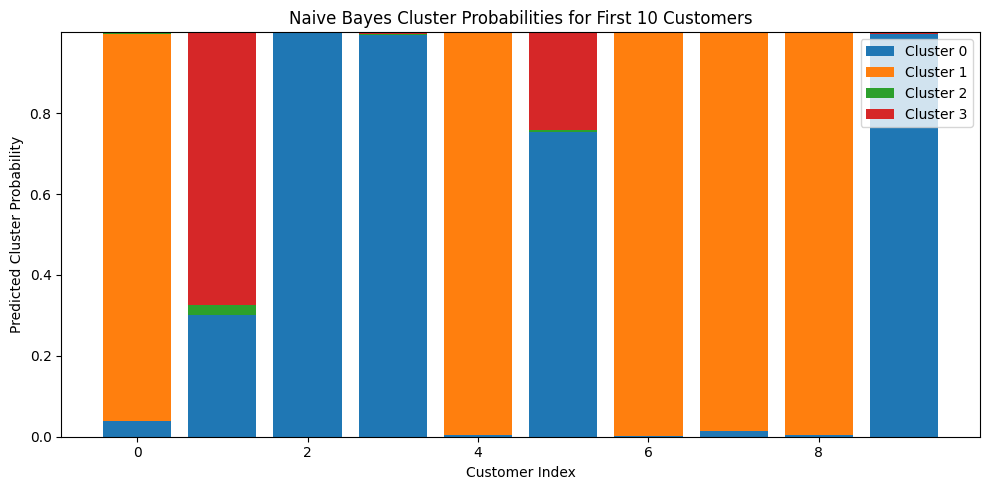


Explained variance ratio:
[0.55502102 0.30249315]
Total explained variance: 0.8575141741259507


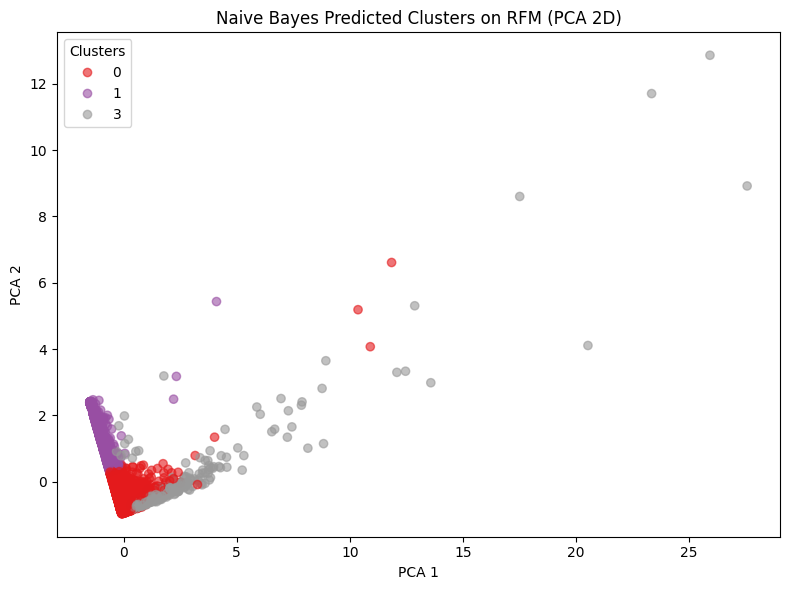

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

# 1. Prepare features and target
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
y = rfm['Cluster']


# 2. Discretize continuous features for Naive Bayes
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
X_binned = kbd.fit_transform(X).astype(int)

# Optional: view discretized data
X_binned_df = pd.DataFrame(X_binned, columns=['Recency_bin', 'Frequency_bin', 'Monetary_bin'])
print("First 5 rows of discretized features:")
print(X_binned_df.head())

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_binned, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Train Categorical Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)

# 5. Prediction and evaluation
y_pred = nb.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 6. Class priors
print("\nClass priors (P(cluster)):")
class_priors = np.exp(nb.class_log_prior_)
for c, p in zip(nb.classes_, class_priors):
    print(f"Cluster {c}: {p:.4f}")

# 7. Conditional probabilities heatmaps
feature_names = ['Recency', 'Frequency', 'Monetary']

for i, feature in enumerate(feature_names):
    cond_prob_df = pd.DataFrame(
        np.exp(nb.feature_log_prob_[i]).T,
        columns=[f"Cluster {c}" for c in nb.classes_]
    )
    cond_prob_df.index = [f"Bin {j}" for j in range(cond_prob_df.shape[0])]

    plt.figure(figsize=(8, 4))
    sns.heatmap(cond_prob_df, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"Conditional Probabilities: P({feature}_bin | Cluster)")
    plt.xlabel("Cluster")
    plt.ylabel(f"{feature} Bin")
    plt.tight_layout()
    plt.show()


# 8. Predicted cluster probabilities (top 10 customers)
y_prob_all = nb.predict_proba(X_binned)

top_n = 10
y_prob_top = y_prob_all[:top_n]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), y_prob_top[:, 0], label="Cluster 0")
plt.bar(range(top_n), y_prob_top[:, 1], bottom=y_prob_top[:, 0], label="Cluster 1")
plt.bar(range(top_n), y_prob_top[:, 2], bottom=y_prob_top[:, 0] + y_prob_top[:, 1], label="Cluster 2")
plt.bar(
    range(top_n),
    y_prob_top[:, 3],
    bottom=y_prob_top[:, 0] + y_prob_top[:, 1] + y_prob_top[:, 2],
    label="Cluster 3"
)

plt.xlabel("Customer Index")
plt.ylabel("Predicted Cluster Probability")
plt.title("Naive Bayes Cluster Probabilities for First 10 Customers")
plt.legend()
plt.tight_layout()
plt.show()

# 9. PCA for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Predict clusters for all customers using Naive Bayes
y_pred_all = nb.predict(X_binned)

# 10. PCA scatter plot colored by Naive Bayes predicted clusters

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pred_all,
    cmap='Set1',
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Naive Bayes Predicted Clusters on RFM (PCA 2D)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.tight_layout()
plt.show()

Naive Bayes Results:

**1. Class Priors**

The class priors show how common each cluster is in the dataset.
Cluster 0 has about 70% of the customers, so it is the largest group (Regular Mid-Value Customers).
Cluster 1 has around 25% of customers, which are mostly low-value or inactive customers.
Cluster 3 is much smaller (about 5%) and represents high-value loyal customers.
Cluster 2 is very rare (only about 0.26%), which explains why it is harder for the model to predict this group accurately.

**2. Conditional Probabilities**

The conditional probabilities help us understand how RFM features relate to each cluster.

Recency:
Cluster 2 customers usually purchased very recently.
Cluster 0 customers have moderate recency.
Cluster 1 customers have not purchased for a long time.

Frequency:
Cluster 2 customers buy very frequently.
Cluster 0 customers buy occasionally.
Cluster 1 customers rarely make purchases.

Monetary:
Cluster 2 customers spend the most (VIP level).
Cluster 0 customers have moderate spending.
Cluster 1 customers spend very little.
This confirms that Cluster 2 are VIP/Elite customers, Cluster 3 are loyal high-value customers, Cluster 1 are low-value or inactive, and Cluster 0 are regular customers.

**3. Classification Report**

The overall accuracy is about 87%, but this is influenced by the large size of Cluster 0.
Cluster 2 has a very low F1-score because it is rare and difficult to predict.
Cluster 3 has a moderate performance.
Clusters 0 and 1 are predicted well because they have more data.
This shows that Naive Bayes is more useful for understanding patterns rather than making perfect predictions.

**4. Discovery Insights**

Cluster 2 customers are VIPs: they buy recently, frequently, and spend the most.
Cluster 1 customers are at risk or inactive and may need re-engagement campaigns.
Cluster 0 customers are regular buyers and could be targeted with upselling or cross-selling.
The probability patterns can be used to design simple marketing rules or recommendations.

**5.Anomaly detection on RFM dataset. The goal is to identify unusual customers, such as extreme VIPs, potential wholesalers, or anomalies. We'll use Isolation Forest (robust for high-value outliers) and Local Outlier Factor (LOF) for comparison**

Total anomalies detected: 44
     CustomerID  Recency  Frequency   Monetary  Cluster  anomaly_score
0       12346.0      326          1   77183.60        3             -1
55      12415.0       24         21  124914.53        2             -1
326     12748.0        1        209   33719.73        2             -1
445     12921.0        9         37   16587.09        3             -1
453     12931.0       22         15   42055.96        3             -1


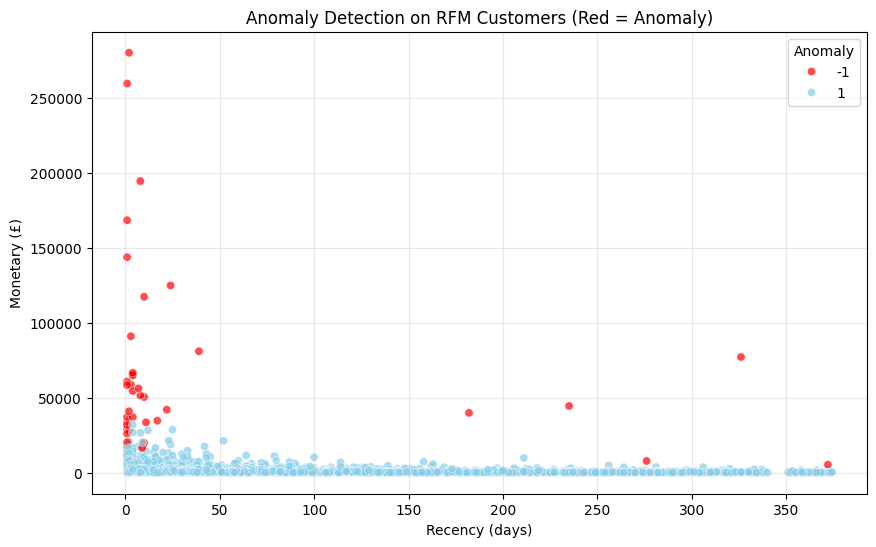

Top potential VIP/wholesale or unusual customers:
      CustomerID  Recency  Frequency   Monetary
1689     14646.0        2         73  280206.02
4201     18102.0        1         60  259657.30
3728     17450.0        8         46  194550.79
3008     16446.0        1          2  168472.50
1879     14911.0        1        201  143825.06
55       12415.0       24         21  124914.53
1333     14156.0       10         55  117379.63
3771     17511.0        3         31   91062.38
2702     16029.0       39         63   81024.84
0        12346.0      326          1   77183.60


In [ ]:
# 4. Anomaly Detection on RFM

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Use Recency, Frequency, Monetary features for anomaly detection
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Isolation Forest
iso_forest = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
rfm['anomaly_score'] = iso_forest.fit_predict(rfm_scaled)

# -1 = anomaly, 1 = normal
anomalies = rfm[rfm['anomaly_score'] == -1]
normal = rfm[rfm['anomaly_score'] == 1]

print(f"Total anomalies detected: {len(anomalies)}")
print(anomalies.head())

# Visualize anomalies in RFM space
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['anomaly_score'],
    palette={1:'skyblue', -1:'red'},
    alpha=0.7
)
plt.title("Anomaly Detection on RFM Customers (Red = Anomaly)")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary (£)")
plt.legend(title='Anomaly')
plt.grid(alpha=0.3)
plt.show()

# Optional: inspect the top potential VIP/wholesale or unusual customers
top_anomalies = anomalies.sort_values('Monetary', ascending=False)
print("Top potential VIP/wholesale or unusual customers:")
print(top_anomalies[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head(10))

Anomalies by Isolation Forest: 44
Anomalies by LOF: 44
Combined anomalies: 74


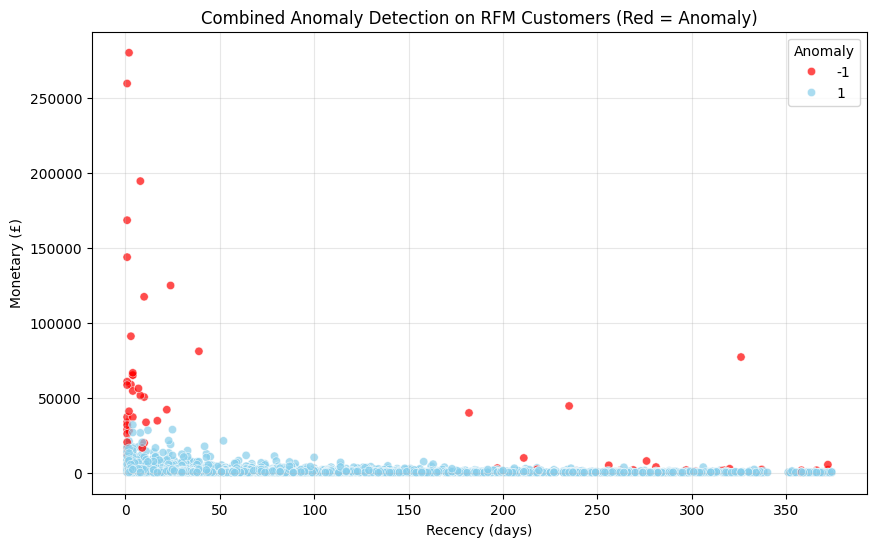

Top potential VIP/wholesale or unusual customers (combined anomalies):
      CustomerID  Recency  Frequency   Monetary
1689     14646.0        2         73  280206.02
4201     18102.0        1         60  259657.30
3728     17450.0        8         46  194550.79
3008     16446.0        1          2  168472.50
1879     14911.0        1        201  143825.06
55       12415.0       24         21  124914.53
1333     14156.0       10         55  117379.63
3771     17511.0        3         31   91062.38
2702     16029.0       39         63   81024.84
0        12346.0      326          1   77183.60


In [ ]:

# 4b. Local Outlier Factor (LOF)
from sklearn.neighbors import LocalOutlierFactor

# Fit LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
rfm['lof_anomaly'] = lof.fit_predict(rfm_scaled)  # -1 = anomaly, 1 = normal

# Compare Isolation Forest and LOF
rfm['combined_anomaly'] = rfm.apply(lambda row: -1 if row['anomaly_score'] == -1 or row['lof_anomaly'] == -1 else 1, axis=1)

# Count anomalies
print(f"Anomalies by Isolation Forest: {sum(rfm['anomaly_score']==-1)}")
print(f"Anomalies by LOF: {sum(rfm['lof_anomaly']==-1)}")
print(f"Combined anomalies: {sum(rfm['combined_anomaly']==-1)}")

# Visualize combined anomalies
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['combined_anomaly'],
    palette={1:'skyblue', -1:'red'},
    alpha=0.7
)
plt.title("Combined Anomaly Detection on RFM Customers (Red = Anomaly)")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary (£)")
plt.legend(title='Anomaly')
plt.grid(alpha=0.3)
plt.show()

# Inspect top potential VIP/wholesale or unusual customers
top_combined_anomalies = rfm[rfm['combined_anomaly'] == -1].sort_values('Monetary', ascending=False)
print("Top potential VIP/wholesale or unusual customers (combined anomalies):")
print(top_combined_anomalies[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head(10))

As the dataset, it seems that the really extreme values in Monetary and Frequency are having the biggest impact on finding anomalies. Both Isolation Forest and LOF end up flagging the same customers with either very high spending or unusual buying patterns, so their results overlap a lot.
A few observations from the top anomalies:

CustomerID 14646 and 18102 – very low Recency (2 days or 1 day), very high Frequency or Monetary → likely VIP or wholesale buyers.
CustomerID 14911 – extreme Frequency of 201 → probably bulk purchases, maybe company accounts.
CustomerID 12346 – extreme Recency of 326 days but low Monetary → could be long-dormant customer or one-time bulk buyer.
Main takeaway: The anomaly detection is working as expected. It points out both super high-value customers and those with unusual buying behavior.